In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 12}

plt.rc('font', **font)
plot_fs = 12

plt.rc('font', family='serif', serif='Times')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)
plt.rc('axes', labelsize=10)
mpl.rcParams['lines.dashed_pattern'] = [2, 2]
mpl.rcParams['lines.linewidth'] = 1.0

import pathlib
cur_dir = pathlib.Path().cwd()
parent_dir = cur_dir.parent

import sys
print(sys.version)
sys.path.append('../')

from models.powertrain.bounded_powertrain import Bounded_powertrain
from models.kinematic.ideal_diff_drive import Ideal_diff_drive
from models.learning.blr_slip import SlipBayesianLinearRegression, FullBodySlipBayesianLinearRegression
from models.learning.blr_slip_acceleration import SlipAccelerationBayesianLinearRegression, FullBodySlipAccelerationBayesianLinearRegression
from models.kinematic.ICR_based import *
from models.kinematic.Perturbed_unicycle import *
from models.kinematic.enhanced_kinematic import *
from NicolasSamson.script.extractors import * 
from util.transform_algebra import *
from util.util_func import *
from data_utils.dataset_parser import *

3.10.12 (main, Jul 19 2024, 11:05:56) [GCC 11.4.0]


Import le dataset

In [2]:
surface_type = 'gravel'

if surface_type == 'gravel':
    path_2_dataset = '../NicolasSamson/drive_datasets/warthog/wheels/ice/ral2023/model_training_datasets/acceleration_dataset.pkl'
    global_save_path_ = '../NicolasSamson/analysis_why_metric/gravel'
    color_background = "lightgrey"

if surface_type == 'ice':
    path_2_dataset = '../NicolasSamson/drive_datasets/warthog/wheels/gravel/ral2023/model_training_datasets/acceleration_dataset.pkl'
    global_save_path_ = '../NicolasSamson/analysis_why_metric/ice'
    color_background = "lightblue"

df_acceleration = pd.read_pickle(path_2_dataset)

print_column_unique_column(df_acceleration)

['init_icp_x' 'init_icp_y' 'init_icp_z' 'init_icp_roll' 'init_icp_pitch'
 'init_icp_yaw' 'calib_step' 'cmd_left' 'cmd_right' 'left_wheel_vel'
 'right_wheel_vel' 'icp_x' 'icp_y' 'icp_z' 'icp_roll' 'icp_pitch'
 'icp_yaw' 'imu_yaw' 'icp_vx' 'icp_vy' 'icp_omega' 'steady_state_mask'
 'transitory_state_mask' 'imu_acceleration_x' 'imu_acceleration_y'
 'imu_acceleration_z' 'gt_icp_x' 'gt_icp_y' 'gt_icp_z' 'gt_icp_roll'
 'gt_icp_pitch' 'gt_icp_yaw' 'transitory_vel_left' 'transitory_vel_right'
 'idd_vel_x' 'idd_vel_y' 'idd_vel_yaw' 'icp_interpolated_x'
 'icp_interpolated_y' 'icp_interpolated_yaw'
 'icp_corrected_interpolated_x' 'icp_corrected_interpolated_y' 'icp_vel_x'
 'icp_vel_y' 'icp_vel_yaw' 'body_vel_disturption_x'
 'body_vel_disturption_y' 'body_vel_disturption_yaw' 'idd_acceleration_x'
 'idd_acceleration_y' 'idd_acceleration_yaw' 'icp_acceleration_x'
 'icp_acceleration_y' 'icp_acceleration_yaw']


Plot the 3D graph showing the evolution of the command and the ground truth

Text(0.5, 0, 'X speed [m/s]')

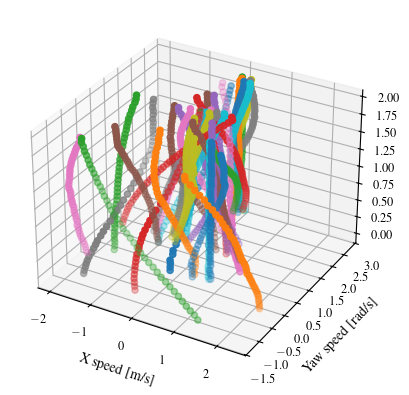

In [3]:
print_column_unique_column


icep_vel_x = column_type_extractor(df_acceleration, 'icp_vel_x',verbose=False)
icep_vel_yaw = column_type_extractor(df_acceleration, 'icp_vel_yaw',verbose=False)
time = create_time_axe(0.05,icep_vel_x.shape[1])


fig = plt.figure(figsize=plt.figaspect(0.5))
axs = fig.add_subplot(1, 1, 1, projection='3d')

for i in range(icep_vel_x.shape[1]):
    axs.scatter(icep_vel_x[i,:],icep_vel_yaw[i,:],time)

axs.set_ylabel("Yaw speed [rad/s]")
axs.set_xlabel("X speed [m/s]")



Calculate the body command

Text(0.5, 0, 'X speed [m/s]')

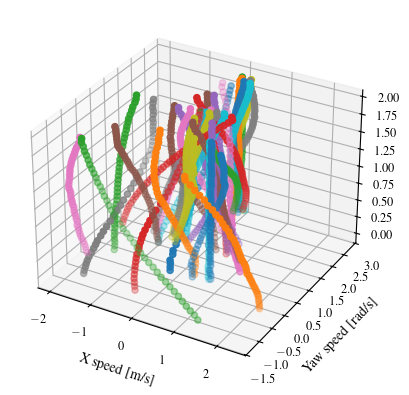

In [4]:
print_column_unique_column


icep_vel_x = column_type_extractor(df_acceleration, 'icp_vel_x',verbose=False)
icep_vel_yaw = column_type_extractor(df_acceleration, 'icp_vel_yaw',verbose=False)
time = create_time_axe(0.05,icep_vel_x.shape[1])


fig = plt.figure(figsize=plt.figaspect(0.5))
axs = fig.add_subplot(1, 1, 1, projection='3d')

for i in range(icep_vel_x.shape[1]):
    axs.scatter(icep_vel_x[i,:],icep_vel_yaw[i,:],time)

axs.set_ylabel("Yaw speed [rad/s]")
axs.set_xlabel("X speed [m/s]")



Compute the mean command vel with the last 2 second window and the ground truth based on ICP_VEL by calculating the mean of ICP vel on the last window. 

Hypothesis: 
1. The body vel is in steady state
2. The smoothing done by Dom is good
3. The noise on ICP is symmetrical
4. The noise on encoder measurement is symmetrical

In [5]:

# Steady state keeping
df_steady_state = df_acceleration[df_acceleration['steady_state_mask'] == 1]
print(df_steady_state.shape)


# Remove the first window
df_last_window = df_steady_state.drop_duplicates(subset=['steady_state_mask','calib_step'],keep='last')
#print(df_last_window.shape)

print(df_last_window.shape)
 
cmd_left = np.mean(column_type_extractor(df_last_window, 'cmd_l',verbose=False),axis=1)
cmd_right = np.mean(column_type_extractor(df_last_window, 'cmd_r',verbose=False),axis=1)
cmd_vel = np.vstack((cmd_left,cmd_right))
body_vel = compute_body_vel_IDD(cmd_vel , robot='warthog-wheel')

icp_vel_x = np.mean(column_type_extractor(df_last_window, 'icp_vel_x',verbose=False),axis=1)
icp_vel_yaw = np.mean(column_type_extractor(df_last_window, 'icp_vel_yaw',verbose=False),axis=1)
body_vel_icp_mean = np.vstack((icp_vel_x,icp_vel_yaw))

raw_icp_vel_x_mean = np.mean(column_type_extractor(df_last_window, 'raw_icp_vel_x',verbose=False),axis=1)
raw_icp_vel_yaw_mean = np.mean(column_type_extractor(df_last_window, 'raw_icp_vel_yaw',verbose=False),axis=1)



odom_speed_l = np.mean(column_type_extractor(df_last_window, 'left_wheel_vel',verbose=False),axis=1)
odom_speed_right = np.mean(column_type_extractor(df_last_window, 'right_wheel_vel',verbose=False),axis=1)


verbose=True
if verbose ==True:
    print(f"cmd_shape {cmd_vel.shape}")
    print(f"body_vel_icp_mean {body_vel_icp_mean.shape}")
    


(394, 1458)
(197, 1458)
cmd_shape (2, 197)
body_vel_icp_mean (2, 197)


/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Plot the command:

Note that the yaw angle in the the smooth version is the IMU


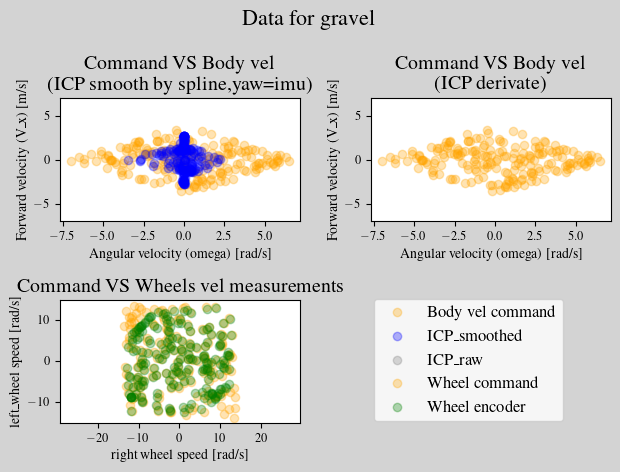

In [6]:

fig, axs = plt.subplots(2,2)
alpha_parama= 0.3
axs[0][0].scatter(body_vel[1,:],body_vel[0,:],color = "orange",label='Body vel command',alpha=alpha_parama)
axs[0][0].scatter(icp_vel_x,icp_vel_yaw,color = "blue",label='ICP_smoothed',alpha=alpha_parama)
axs[0][0].set_xlabel("Angular velocity (omega) [rad/s]")
axs[0][0].set_ylabel("Forward velocity (V_x) [m/s]")
#axs[0][0].legend(loc='center left')

axs[0][1].scatter(body_vel[1,:],body_vel[0,:],color = "orange",alpha=alpha_parama)
axs[0][1].scatter(raw_icp_vel_x_mean,raw_icp_vel_yaw_mean,color = "grey",label='ICP_raw',alpha=alpha_parama)
axs[0][1].set_xlabel("Angular velocity (omega) [rad/s]")
axs[0][1].set_ylabel("Forward velocity (V_x) [m/s]")
#axs[0][1].legend(loc='center left')

axs[1][0].scatter(cmd_vel[0,:],cmd_vel[1,:],color="orange",label="Wheel command",alpha=alpha_parama)
axs[1][0].scatter(odom_speed_l,odom_speed_right,color="green",label="Wheel encoder",alpha=alpha_parama)
axs[1][0].set_ylabel("left_wheel speed [rad/s]")
axs[1][0].set_xlabel("right wheel speed [rad/s]")
#axs[1][0].legend(loc='upper right')

axs[0][0].set_title("Command VS Body vel \n (ICP smooth by spline,yaw=imu)")
axs[0][1].set_title("Command VS Body vel \n (ICP derivate)")
axs[1][0].set_title("Command VS Wheels vel measurements")

lim_speed_x = 7
lim_speed_yaw = 15
axs[0][0].set_ylim((-lim_speed_x,lim_speed_x))
axs[0][1].set_ylim((-lim_speed_x,lim_speed_x))
axs[1][0].set_ylim((-lim_speed_x,lim_speed_x))
#axs[1][1].set_ylim((y_min,y_max))

l, legends_label = axs[0][0].get_legend_handles_labels()
l1, legends_label_1 = axs[0][1].get_legend_handles_labels()
l2, legends_label_2 = axs[1][0].get_legend_handles_labels()

axs[1][1].set_axis_off()
legends_labels = legends_label+legends_label_1+legends_label_2

lines = l+l1+l2

axs[1][1].legend(lines, legends_labels, loc = 'center', bbox_to_anchor = (0.25, -0.25, 1, 1),
           bbox_transform = plt.gcf().transFigure)
# square plot
#axs[0][0].axis('equal')
#axs[0][1].axis('equal')
axs[1][0].axis('equal')
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()

print('Note that the yaw angle in the the smooth version is the IMU')


In [7]:
print_column_unique_column(df_acceleration)

print(df_acceleration.index)

['init_icp_x' 'init_icp_y' 'init_icp_z' 'init_icp_roll' 'init_icp_pitch'
 'init_icp_yaw' 'calib_step' 'cmd_left' 'cmd_right' 'left_wheel_vel'
 'right_wheel_vel' 'icp_x' 'icp_y' 'icp_z' 'icp_roll' 'icp_pitch'
 'icp_yaw' 'imu_yaw' 'icp_vx' 'icp_vy' 'icp_omega' 'steady_state_mask'
 'transitory_state_mask' 'imu_acceleration_x' 'imu_acceleration_y'
 'imu_acceleration_z' 'gt_icp_x' 'gt_icp_y' 'gt_icp_z' 'gt_icp_roll'
 'gt_icp_pitch' 'gt_icp_yaw' 'transitory_vel_left' 'transitory_vel_right'
 'idd_vel_x' 'idd_vel_y' 'idd_vel_yaw' 'icp_interpolated_x'
 'icp_interpolated_y' 'icp_interpolated_yaw'
 'icp_corrected_interpolated_x' 'icp_corrected_interpolated_y' 'icp_vel_x'
 'icp_vel_y' 'icp_vel_yaw' 'body_vel_disturption_x'
 'body_vel_disturption_y' 'body_vel_disturption_yaw' 'idd_acceleration_x'
 'idd_acceleration_y' 'idd_acceleration_yaw' 'icp_acceleration_x'
 'icp_acceleration_y' 'icp_acceleration_yaw']
RangeIndex(start=0, stop=591, step=1)


To do:

1. V/rifier le pipeleine menant a wheel odometry measurement
    1. But s'assurer que de comprendre le pipeline 
2. Valider le r/gime permanent 'a la troisieme fenetre
3. Cr/er un dataparser qui herite et calcule et store la vitesse sans filtre de ICP
4. Comparaison de ICP sans et avec filtre. 
5. Analyser le graph regime 


## The body vel and the wheels are in steady state ?





In [8]:
verbose = True
rate = 0.05 #s
n_step = 40 *3


left_wheel_vel = column_type_extractor(df_acceleration, 'left_wheel_vel',verbose=verbose)
right_wheel_vel = column_type_extractor(df_acceleration, 'right_wheel_vel',verbose=verbose)
icp_vel_x = column_type_extractor(df_acceleration, 'icp_vel_x',verbose=verbose)
icp_vel_yaw = column_type_extractor(df_acceleration, 'icp_vel_yaw',verbose=verbose)
body_vel_icp = np.vstack((icp_vel_x,icp_vel_yaw))


raw_icp_vel_x = column_type_extractor(df_acceleration, 'raw_icp_vel_x',verbose=False)
raw_icp_vel_yaw = column_type_extractor(df_acceleration, 'raw_icp_vel_yaw',verbose=False)
print_column_unique_column(df_acceleration)
column_to_reshape = [left_wheel_vel,right_wheel_vel,
                    icp_vel_x,icp_vel_yaw, body_vel_icp,
                    raw_icp_vel_x,raw_icp_vel_yaw]


for i in range(len(column_to_reshape)):
    first_index = column_to_reshape[i].shape[0]//3
    total_info = column_to_reshape[i].shape[0]* column_to_reshape[i].shape[1]
    second_size = total_info//first_index
    reshape_size = (first_index, second_size)
    column_to_reshape[i] = column_to_reshape[i].reshape(reshape_size)

left_wheel_vel,right_wheel_vel, icp_vel_x,icp_vel_yaw, body_vel_icp,raw_icp_vel_x,raw_icp_vel_yaw = column_to_reshape

time_axis = create_time_axe(rate,n_step)



________left_wheel_vel________
The column type: left_wheel_vel
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 12.941616403537953
Minimum -13.041972835527627
______________________________
________right_wheel_vel________
The column type: right_wheel_vel
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 12.919799787888024
Minimum -12.705996954518719
_______________________________
________icp_vel_x________
The column type: icp_vel_x
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 2.711354718615302
Minimum -3.478417039510205
_________________________
________icp_vel_yaw________
The column type: icp_vel_yaw
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 2.755186351506815
Minimum -3.3384444392036343
___________________________


In [9]:
cmd_left_all = column_type_extractor(df_acceleration, 'cmd_l',verbose=False)
cmd_right_all = column_type_extractor(df_acceleration, 'cmd_r',verbose=False)

cmd_body_vel_yaw_all = []
cmd_body_vel_x_all = []

print(cmd_right_all.shape)
n_step = cmd_left_all.shape[0] 
horizon_length = cmd_left_all.shape[1]
total_info = n_step * horizon_length
final_shape = ( total_info//(horizon_length *3), horizon_length *3)

# Compute the body 
for calib_step in range(n_step):
    for i in range(horizon_length): 
        cmd_vel_wheel_i = np.array([cmd_left_all[calib_step,i],cmd_right_all[calib_step,i]])
    
        body_vel_i = compute_body_vel_IDD(cmd_vel_wheel_i , robot='warthog-wheel')
        cmd_body_vel_yaw_all.append(body_vel_i[1])
        cmd_body_vel_x_all.append(body_vel_i[0])

cmd_body_vel_x_all = np.array(cmd_body_vel_x_all).reshape(final_shape)
cmd_body_vel_yaw_all = np.array(cmd_body_vel_yaw_all).reshape(final_shape)
cmd_left_all_reshape = cmd_left_all.reshape(final_shape)
cmd_right_all_reshape = cmd_right_all.reshape(final_shape)



(591, 40)


Create the normalised results_array


### Graph

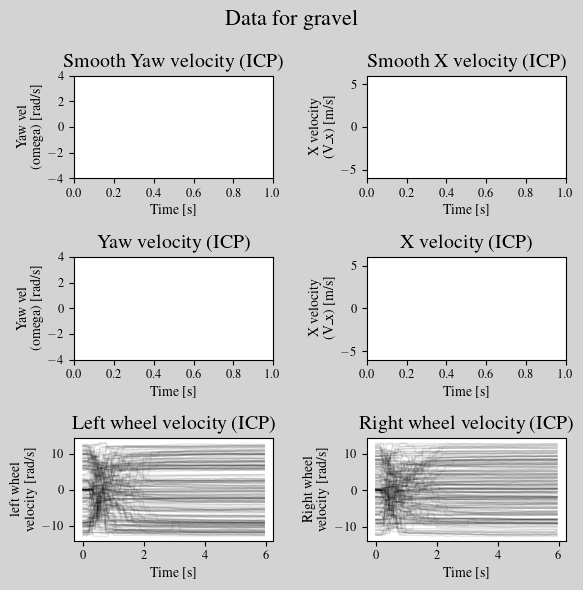

In [10]:
fig, axs = plt.subplots(3,2)
fig.set_size_inches(6,6)
alpha = 0.1 

for i in range(icp_vel_x.shape[0]):
    #axs[0][0].plot(time_axis,icp_vel_x[i,:],label="ICP_raw",color="black",alpha=alpha)
    #axs[0][0].plot(time_axis,cmd_body_vel_x_all[i,:],label="CMD_body")
    
    #axs[0][1].plot(time_axis,icp_vel_yaw[i,:],label="ICP_raw",color="black",alpha=alpha)
    #axs[0][1].plot(time_axis,cmd_body_vel_yaw_all[i,:],label="CMD_body")
    

    axs[2][1].plot(time_axis,right_wheel_vel[i,:],label="wheel odometry",color="black",alpha=alpha)
    #axs[1][1].plot(time_axis,cmd_right_all_reshape[i,:],label="wheel command",color="black",alpha=alpha)
    
    axs[2][0].plot(time_axis,left_wheel_vel[i,:],label="wheel odometry",color="black",alpha=alpha)
    #axs[1][0].plot(time_axis,cmd_left_all_reshape[i,:],label="wheel command",color="black",alpha=alpha)
    
    #axs[1][0].plot(time_axis,raw_icp_vel_x[i,:],label="ICP_raw",color="black",alpha=alpha)
    #axs[1][1].plot(time_axis,raw_icp_vel_yaw[i,:],label="ICP_raw",color="black",alpha=alpha)
    
axs[0][0].set_title("Smooth Yaw velocity (ICP)")
axs[0][1].set_title("Smooth X velocity (ICP)")
axs[1][0].set_title("Yaw velocity (ICP)")
axs[1][1].set_title("X velocity (ICP)")

axs[2][0].set_title("Left wheel  velocity (ICP)")
axs[2][1].set_title("Right wheel velocity (ICP)")

axs[0][0].set_ylabel("Yaw vel \n (omega) [rad/s]")
axs[0][1].set_ylabel("X velocity \n (V_x) [m/s]")


axs[1][0].set_ylabel("Yaw vel \n (omega) [rad/s]")
axs[1][1].set_ylabel("X velocity \n (V_x) [m/s]")

axs[2][0].set_ylabel("left wheel \n velocity [rad/s]")
axs[2][1].set_ylabel("Right wheel\n velocity [rad/s]")

axs[0][1].set_xlabel("Time [s]")
axs[1][1].set_xlabel("Time [s]")
axs[0][0].set_xlabel("Time [s]")
axs[1][0].set_xlabel("Time [s]")
axs[2][0].set_xlabel("Time [s]")
axs[2][1].set_xlabel("Time [s]")

axs[0][0].set_ylim(-4,4)
axs[1][0].set_ylim(-4,4)

axs[0][1].set_ylim(-6,6)
axs[1][1].set_ylim(-6,6)
#axs[0][0].legend()
#axs[0][1].legend()
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()



Il faudrait une normalisation des graphes pour que l,on puisse les affiches

In [11]:
#left_wheel_vel,right_wheel_vel, icp_vel_x,icp_vel_yaw, body_vel_icp = column_to_reshape
def compute_6s_shape(column_to_reshape):
    first_index = column_to_reshape.shape[0]//3
    total_info = column_to_reshape.shape[0]* column_to_reshape.shape[1]
    second_size = total_info//first_index
    reshape_size = (first_index, second_size)
    return reshape_size

def compute_operation_points_and_step(res_2d_array,cmd_2d_array,reshape=True):
    noramlizer_index = 1
    
    
    operation_point = (res_2d_array[:,0:4].mean(axis=1)).reshape((res_2d_array.shape[0],1))
    command_abso = cmd_2d_array[:,noramlizer_index].reshape((res_2d_array.shape[0],1)) 
    steps = command_abso - operation_point

    return operation_point,steps


def normalizer_2d_array(res_2d_array,cmd_2d_array):
    """To normalize the step answer by the first column of the command vector
    Args:
        res_2d_array (_type_): the nb_calibration_stepxhorizon_length(40 or 120) AKA 2 or 6second
        cmd_2d_array (_type_): _description_
    Returns:
        _type_: _description_
    """
    operation_point,steps = compute_operation_points_and_step(res_2d_array,cmd_2d_array)

    normalizer_coefficient = 1/steps

    centered_2d_array = res_2d_array - operation_point
    normalize_2d_array = centered_2d_array * normalizer_coefficient
    
    normalized_cmd_2d_array = np.ones(normalize_2d_array.shape)
    return normalize_2d_array,normalized_cmd_2d_array


#,, icp_vel_x,icp_vel_yaw, body_vel_icp 
normalized_left_wheel,normalized_cmd_left_all_reshape = normalizer_2d_array(left_wheel_vel,cmd_left_all_reshape)
normalized_right_wheel_vel,normalized_cmd_right_all_reshape = normalizer_2d_array(right_wheel_vel,cmd_right_all_reshape)
normalized_icp_vel_x, noramilzed_cmd_body_vel_x_all = normalizer_2d_array(icp_vel_x, cmd_body_vel_x_all)
normalized_icp_vel_yaw, normalized_cmd_body_vel_yaw_all = normalizer_2d_array(icp_vel_yaw, cmd_body_vel_yaw_all)



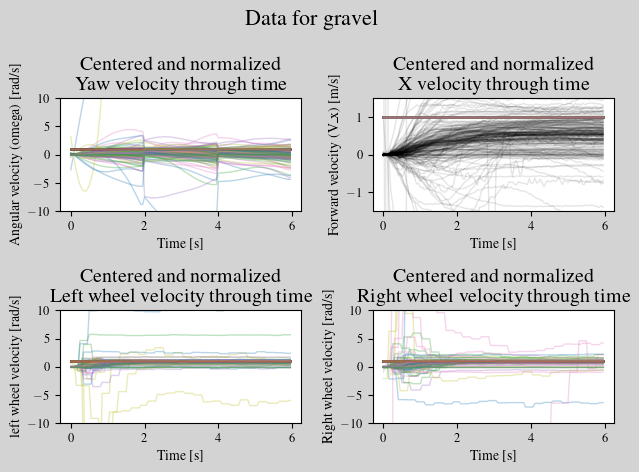

In [12]:
fig, axs = plt.subplots(2,2)

for i in range(normalized_left_wheel.shape[0]):
    axs[0][0].plot(time_axis,normalized_icp_vel_x[i,:],label="ICP_raw",alpha=alpha_parama)
    axs[0][0].plot(time_axis,noramilzed_cmd_body_vel_x_all[i,:],label="CMD_body",alpha=0.1)
    axs[0][1].plot(time_axis,normalized_icp_vel_yaw[i,:],label="ICP_raw",alpha=0.1,lw=1, color='black')
    axs[0][1].plot(time_axis,normalized_cmd_body_vel_yaw_all[i,:],label="CMD_body",alpha=alpha_parama,lw=1)


    axs[1][1].plot(time_axis,normalized_right_wheel_vel[i,:],label="wheel odometry",alpha=alpha_parama)
    axs[1][1].plot(time_axis,normalized_cmd_right_all_reshape[i,:],label="wheel command",alpha=alpha_parama)
    
    axs[1][0].plot(time_axis,normalized_left_wheel[i,:],label="wheel odometry",alpha=alpha_parama)
    axs[1][0].plot(time_axis,normalized_cmd_left_all_reshape[i,:],label="wheel command",alpha=alpha_parama)
    
axs[0][0].set_title("Centered and normalized \n Yaw velocity through time")
axs[0][1].set_title("Centered and normalized \n X velocity through time")
axs[1][0].set_title("Centered and normalized \n Left wheel velocity through time")
axs[1][1].set_title("Centered and normalized \n Right wheel velocity through time")

axs[0][0].set_ylabel("Angular velocity (omega) [rad/s]")
axs[0][1].set_ylabel("Forward velocity (V_x) [m/s]")

axs[1][0].set_ylabel("left wheel velocity [rad/s]")
axs[1][1].set_ylabel("Right wheel velocity [rad/s]")

axs[0][1].set_xlabel("Time [s]")
axs[1][1].set_xlabel("Time [s]")
axs[0][0].set_xlabel("Time [s]")
axs[1][0].set_xlabel("Time [s]")

y_min = -10
y_max = 10
axs[0][0].set_ylim((y_min,y_max))
axs[0][1].set_ylim((-1.5,1.5))
axs[1][0].set_ylim((y_min,y_max))
axs[1][1].set_ylim((y_min,y_max))
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()



It seems that ice has less noise in the begining pf the experiment. Could it be caused by an easier initial point (point operations)?

Est-ce qu'il faudrait que je visualise la vitesse angulaire dans un autre r/f/rent pour /viter le wrap to pie ? 



In [13]:
operation_point_left_wheel,steps_cmd_left_all_reshape = compute_operation_points_and_step(left_wheel_vel,cmd_left_all_reshape)
operation_point_right_wheel_vel,steps_cmd_right_all_reshape = compute_operation_points_and_step(right_wheel_vel,cmd_right_all_reshape)
operation_point_icp_vel_x, steps_cmd_body_vel_x_all = compute_operation_points_and_step(icp_vel_x, cmd_body_vel_x_all)
operation_point_icp_vel_yaw, steps_cmd_body_vel_yaw_all = compute_operation_points_and_step(icp_vel_yaw, cmd_body_vel_yaw_all)



Note that the yaw angle in the the smooth version is the IMU


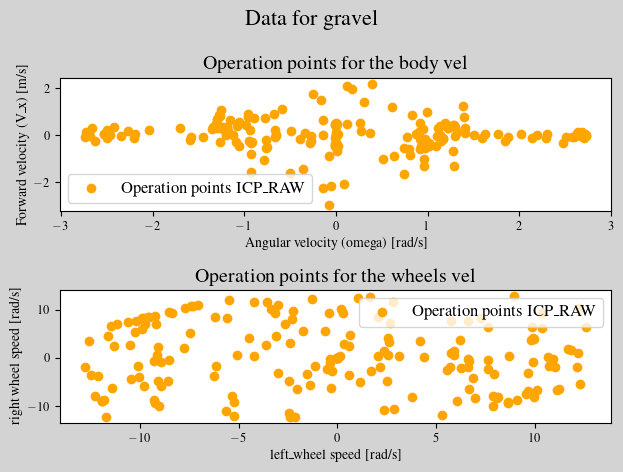

In [14]:

fig, axs = plt.subplots(2,1)

axs[0].scatter(operation_point_icp_vel_yaw,operation_point_icp_vel_x,
            color = "orange",label='Operation points ICP_RAW')

axs[0].set_xlabel("Angular velocity (omega) [rad/s]")
axs[0].set_ylabel("Forward velocity (V_x) [m/s]")
axs[0].legend()

axs[1].scatter(operation_point_left_wheel,operation_point_right_wheel_vel,
            color="orange",label="Operation points ICP_RAW")
#axs[1].scatter(odom_speed_l,odom_speed_right,color="green",label="Wheel encoder")
axs[1].set_xlabel("left_wheel speed [rad/s]")
axs[1].set_ylabel("right wheel speed [rad/s]")
axs[1].legend()

axs[0].set_title("Operation points for the body vel")
axs[1].set_title("Operation points for the wheels vel")

fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()

print('Note that the yaw angle in the the smooth version is the IMU')


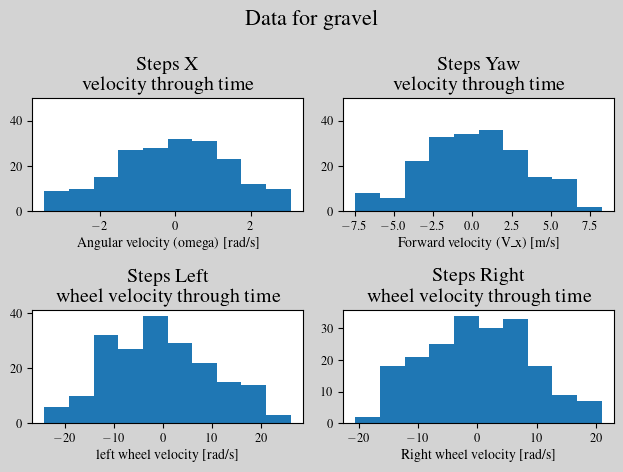

In [15]:



fig, axs = plt.subplots(2,2)


axs[0][0].hist(steps_cmd_body_vel_x_all,label="ICP_raw")
axs[0][1].hist(steps_cmd_body_vel_yaw_all,label="ICP_raw")


axs[1][1].hist(steps_cmd_right_all_reshape,label="wheel odometry")
axs[1][0].hist(steps_cmd_left_all_reshape,label="wheel odometry")

axs[0][0].set_title("Steps X \n velocity through time")
axs[0][1].set_title("Steps Yaw \n velocity through time")
axs[1][0].set_title("Steps Left \n wheel velocity through time")
axs[1][1].set_title("Steps Right \n wheel velocity through time")

axs[0][0].set_xlabel("Angular velocity (omega) [rad/s]")
axs[0][1].set_xlabel("Forward velocity (V_x) [m/s]")

axs[1][0].set_xlabel("left wheel velocity [rad/s]")
axs[1][1].set_xlabel("Right wheel velocity [rad/s]")


y_min = 0
y_max = 50
axs[0][0].set_ylim((y_min,y_max))
axs[0][1].set_ylim((y_min,y_max))
#axs[1][0].set_ylim((y_min,y_max))
#axs[1][1].set_ylim((y_min,y_max))
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()



### With what the error is correlated: 
1. The point d'operation
2. Just the command 
3. The centered command (U)

In [16]:
operation_point_left_wheel,steps_cmd_left_all_reshape = compute_operation_points_and_step(left_wheel_vel,cmd_left_all_reshape)
operation_point_right_wheel_vel,steps_cmd_right_all_reshape = compute_operation_points_and_step(right_wheel_vel,cmd_right_all_reshape)
operation_point_icp_vel_x, steps_cmd_body_vel_x_all = compute_operation_points_and_step(icp_vel_x, cmd_body_vel_x_all)
operation_point_icp_vel_yaw, steps_cmd_body_vel_yaw_all = compute_operation_points_and_step(icp_vel_yaw, cmd_body_vel_yaw_all)
#operation_point_icp_vel_y, steps_cmd_body_vel_y_all = compute_operation_points_and_step(icp_vel_y, cmd_body_vel_y_all)

#print_column_unique_column(df_acceleration)

idd_vel_X_error_ts = column_type_extractor(df_acceleration, "body_vel_disturption_x",steady_state=False)
idd_vel_y_error_ts = column_type_extractor(df_acceleration, "body_vel_disturption_y",steady_state=False)
idd_vel_yaw_error_ts = column_type_extractor(df_acceleration, "body_vel_disturption_yaw",steady_state=False)


#idd_vel_X_error_steady = column_type_extractor(df_acceleration, "body_vel_disturption_x")
#idd_vel_y_error_steady = column_type_extractor(df_acceleration, "body_vel_disturption_y")
#idd_vel_yaw_error_steady = column_type_extractor(df_acceleration, "body_vel_disturption_yaw")


In [17]:
def compute_correlation_coeff(x,y):
    """Based on that definition https://en.wikipedia.org/wiki/Correlation

    Args:
        x (_type_): _description_
        y (_type_): _description_
    """

    cov_matrix= np.cov(x,y,rowvar=False)
    

    coeff_corr = cov_matrix[1,0]/ (cov_matrix[0,0] * cov_matrix[1,1])
    print(coeff_corr)
    

compute_correlation_coeff(steps_cmd_body_vel_yaw_all,np.mean(idd_vel_yaw_error_ts,axis=1))
compute_correlation_coeff(steps_cmd_body_vel_x_all,np.mean(idd_vel_X_error_ts,axis=1))

0.19884722324862283
0.5944384320721087


(197, 40)
(197, 1)


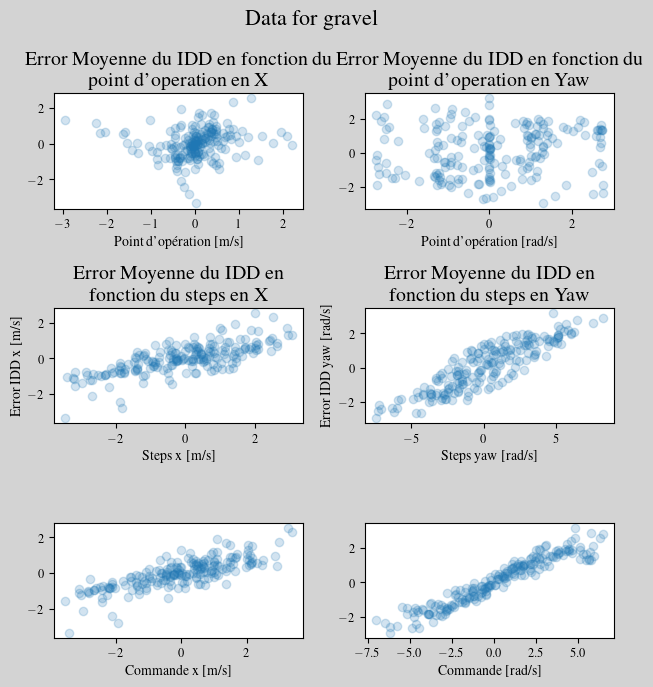

In [18]:



fig, axs = plt.subplots(3,2)
fig.set_figheight(7)
print(idd_vel_X_error_ts.shape)
print(operation_point_icp_vel_x.shape)
alpha = 0.2
axs[0][0].scatter(operation_point_icp_vel_x,np.mean(idd_vel_X_error_ts,axis=1),alpha=alpha)

axs[0][1].scatter(operation_point_icp_vel_yaw,np.mean(idd_vel_yaw_error_ts,axis=1),alpha=alpha)


axs[1][0].scatter(steps_cmd_body_vel_x_all,np.mean(idd_vel_X_error_ts,axis=1),alpha=alpha)
axs[1][1].scatter(steps_cmd_body_vel_yaw_all,np.mean(idd_vel_yaw_error_ts,axis=1),alpha=alpha)

axs[2][0].scatter(cmd_body_vel_x_all[:,2],np.mean(idd_vel_X_error_ts,axis=1),alpha=alpha)
axs[2][1].scatter(cmd_body_vel_yaw_all[:,2],np.mean(idd_vel_yaw_error_ts,axis=1),alpha=alpha)


axs[0][0].set_title("Error Moyenne du IDD en fonction du \n point d'operation en X")
axs[0][1].set_title("Error Moyenne du IDD en fonction du \n point d'operation en Yaw")
axs[1][0].set_title("Error Moyenne du IDD en \n fonction du  steps en X")
axs[1][1].set_title("Error Moyenne du IDD en \n fonction du  steps en Yaw")

axs[0][0].set_xlabel("Point d'opération [m/s]")
axs[0][1].set_xlabel("Point d'opération [rad/s]")
#axs[0][0].set_ylabel("Error IDD x [m/s]")
#axs[0][1].set_ylabel("Error IDD yaw [rad/s]")

axs[1][0].set_xlabel("Steps x [m/s]")
axs[1][1].set_xlabel("Steps yaw [rad/s]")
axs[1][0].set_ylabel("Error IDD x [m/s]")
axs[1][1].set_ylabel("Error IDD yaw [rad/s]")


axs[2][0].set_xlabel("Commande x [m/s]")
axs[2][1].set_xlabel("Commande [rad/s]")
#axs[2][0].set_ylabel("Error IDD x [m/s]")
#axs[2][1].set_ylabel("Error IDD yaw [rad/s]")

y_min = 0
y_max = 50
#axs[0][0].set_ylim((y_min,y_max))
#axs[0][1].set_ylim((y_min,y_max))
#axs[1][0].set_ylim((y_min,y_max))
#axs[1][1].set_ylim((y_min,y_max))
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()



# Conclusion
Il est nécessaire de réaliser le diamant non pas avec la commande et le résultat, mes avec la commande - le point d'opération. De cette facon, on obtient une réelle explication de la difficitultée.
 



In [19]:
cmd_left = np.mean(column_type_extractor(df_last_window, 'cmd_l',verbose=False),axis=1)
cmd_right = np.mean(column_type_extractor(df_last_window, 'cmd_r',verbose=False),axis=1)
cmd_vel = np.vstack((cmd_left,cmd_right))
body_vel = compute_body_vel_IDD(cmd_vel , robot='warthog-wheel')

icp_vel_x = np.mean(column_type_extractor(df_last_window, 'icp_vel_x',verbose=False),axis=1)
icp_vel_yaw = np.mean(column_type_extractor(df_last_window, 'icp_vel_yaw',verbose=False),axis=1)
body_vel_icp_mean = np.vstack((icp_vel_x,icp_vel_yaw))

print(icp_vel_x.shape)

operation_point_left_wheel,steps_cmd_left_all_reshape = compute_operation_points_and_step(left_wheel_vel,cmd_left_all_reshape)
operation_point_right_wheel_vel,steps_cmd_right_all_reshape = compute_operation_points_and_step(right_wheel_vel,cmd_right_all_reshape)


centered_body_vel_x = (body_vel_icp_mean[0,:]).reshape(operation_point_icp_vel_yaw.shape) - operation_point_icp_vel_x 
centered_body_vel_yaw = (body_vel_icp_mean[1,:]).reshape(operation_point_icp_vel_yaw.shape) - operation_point_icp_vel_yaw 
centered_left_wheel_vel = (odom_speed_l).reshape(operation_point_icp_vel_yaw.shape) - operation_point_left_wheel 
centered_right_wheel_vel = (odom_speed_right).reshape(operation_point_icp_vel_yaw.shape) - operation_point_right_wheel_vel 


print(right_wheel_vel.shape)
print(centered_right_wheel_vel.shape)

(197,)
(197, 120)
(197, 1)


Note that the yaw angle in the the smooth version is the IMU


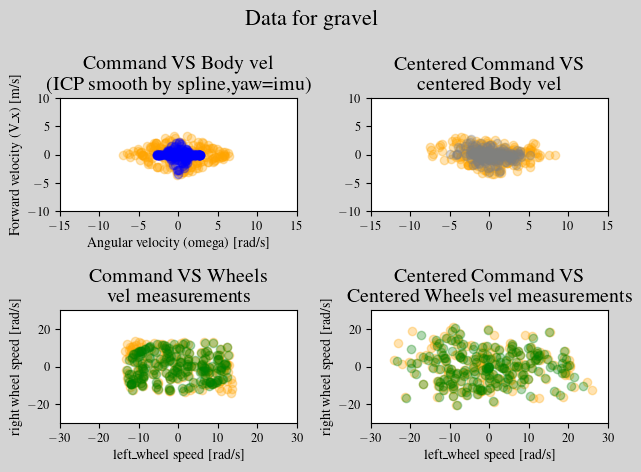

In [20]:

fig, axs = plt.subplots(2,2)
alpha_parama= 0.3
axs[0][0].scatter(body_vel[1,:],body_vel[0,:],color = "orange",label='Body vel command',alpha=alpha_parama)
axs[0][0].scatter(body_vel_icp_mean[1,:],body_vel_icp_mean[0,:],color = "blue",label='ICP_smoothed',alpha=alpha_parama)
axs[0][0].set_xlabel("Angular velocity (omega) [rad/s]")
axs[0][0].set_ylabel("Forward velocity (V_x) [m/s]")
#axs[0][0].legend(loc='center left')

axs[0][1].scatter(steps_cmd_body_vel_yaw_all,steps_cmd_body_vel_x_all,color = "orange",alpha=alpha_parama)
axs[0][1].scatter(centered_body_vel_yaw,centered_body_vel_x,color = "grey",label='ICP_raw',alpha=alpha_parama)
#axs[0][1].set_xlabel("Angular velocity (omega) [rad/s]")
#axs[0][1].set_ylabel("Forward velocity (V_x) [m/s]")
#axs[0][1].legend(loc='center left')

axs[1][0].scatter(cmd_vel[0,:],cmd_vel[1,:],color="orange",label="Wheel command",alpha=alpha_parama)
axs[1][0].scatter(odom_speed_l,odom_speed_right,color="green",label="Wheel encoder",alpha=alpha_parama)
axs[1][0].set_xlabel("left_wheel speed [rad/s]")
axs[1][0].set_ylabel("right wheel speed [rad/s]")
#axs[1][0].legend(loc='upper right')


axs[1][1].scatter(steps_cmd_left_all_reshape,steps_cmd_right_all_reshape,color="orange",label="Wheel command",alpha=alpha_parama)
axs[1][1].scatter(centered_left_wheel_vel,centered_right_wheel_vel,color="green",label="Wheel encoder",alpha=alpha_parama)
axs[1][1].set_xlabel("left_wheel speed [rad/s]")
axs[1][1].set_ylabel("right wheel speed [rad/s]")


axs[0][0].set_title("Command VS Body vel \n (ICP smooth by spline,yaw=imu)")
axs[0][1].set_title("Centered Command VS \n centered Body vel ")
axs[1][0].set_title("Command VS Wheels \n vel measurements")
axs[1][1].set_title("Centered Command VS \n Centered Wheels vel measurements")

#axs[1][0].axis('equal')
#axs[1][1].axis('equal')
wheel = 30

axs[0][0].set_ylim((-10,10))
axs[0][1].set_ylim((-10,10))
axs[1][0].set_ylim((-wheel,wheel))
axs[1][1].set_ylim((-wheel,wheel))

axs[0][0].set_xlim((-15,15))
axs[0][1].set_xlim((-15,15))
axs[1][0].set_xlim((-wheel,wheel))
axs[1][1].set_xlim((-wheel,wheel))


l, legends_label = axs[0][0].get_legend_handles_labels()
l1, legends_label_1 = axs[0][1].get_legend_handles_labels()
l2, legends_label_2 = axs[1][0].get_legend_handles_labels()

#axs[1][1].set_axis_off()
legends_labels = legends_label+legends_label_1+legends_label_2

lines = l+l1+l2

#axs[1][1].legend(lines, legends_labels, loc = 'center', bbox_to_anchor = (0.25, -0.25, 1, 1),
#           bbox_transform = plt.gcf().transFigure)
# square plot
#axs[0][0].axis('equal')
#axs[0][1].axis('equal')


fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()

print('Note that the yaw angle in the the smooth version is the IMU')


In [21]:
print(360*40)

14400
